# Práctica 2: Clustering de Semillas
## Aprendizaje No Supervisado

En esta práctica se aplican técnicas de agrupamiento (clustering) sobre un conjunto de datos que describe distintas características físicas de semillas. El objetivo es comprobar si existen agrupaciones naturales en los datos y evaluar qué técnicas de clustering se ajustan mejor.

Se compararán tres técnicas principales:
- **K-Means**
- **Clustering Jerárquico (Hierarchical Clustering)**
- **DBSCAN**

Para la visualización de los resultados se utilizará una reducción de dimensionalidad mediante PCA a 2 dimensiones. También se analizará la correspondencia entre los clusters generados y las clases originales de semillas.

**Autores:** Raúl Armas Seriñá, Jordan-Ikukele Bomolo Mia  
**Grupo o NIA:** ?

Importamos las librerías necesarias antes de comenzar

In [139]:
# Librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

**Carga del DataSet**

Procedemos a cargar el dataset y prepararlo para el análisis

In [140]:
# Cargar los datos
df = pd.read_csv("semillas.csv")

# Mostrar las primeras filas y la info general
display(df.head())
df.info()

,area,perimetro,compacidad,longitud,anchura,asimetria,surco,clase
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area        210 non-null    float64
 1   perimetro   210 non-null    float64
 2   compacidad  210 non-null    float64
 3   longitud    210 non-null    float64
 4   anchura     210 non-null    float64
 5   asimetria   210 non-null    float64
 6   surco       210 non-null    float64
 7   clase       210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.2 KB


Ahora podemos separar los atributos (X) y las clases (Y). El clustering es no supervisado, por lo que no se va a usar una columna "y" para entrenar (solo para comparar resultados).

In [141]:
X = df.drop("clase", axis=1)
y = df["clase"]

### **Comparativa y Visualización de los Scalers con PCA**

Preparamos los 3 scalers que vamos a probar. PCA necesita que los datos esten escalados, ya que los atributos tienen magnitudes distintas. Sabemos que:

    •	MinMaxScaler: pone cada atributo entre 0 y 1.
	•	StandardScaler: centra la media en 0 y la desv. típica en 1.
	•	RobustScaler: usa la mediana y el IQR → más robusto a outliers.

In [142]:
# Preparar scalers y nombres
scalers = {
    "MinMaxScaler": MinMaxScaler(),
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler()
}

Escalaremos los datos con cada uno de los scalers, los reduciremos a 2 dimensiones con PCA para poder hacer gráficas y mostraremos cada caso en un gráfico 2d.

Ahora vamos a crear una figura con 3 subgráficos en línea (uno para cada escalado). Así, podremos comparar de forma visual los resultados del PCA en cada escalado. (Los gráficos están vacíos, aún no dibujamos nada en ellos)

NOTA: PCA (Análisis de Componentes Principales) es una técnica de reducción de dimensionalidad

Text(0.5, 0.98, 'Comparación visual de escalados con PCA (sin usar la clase)')

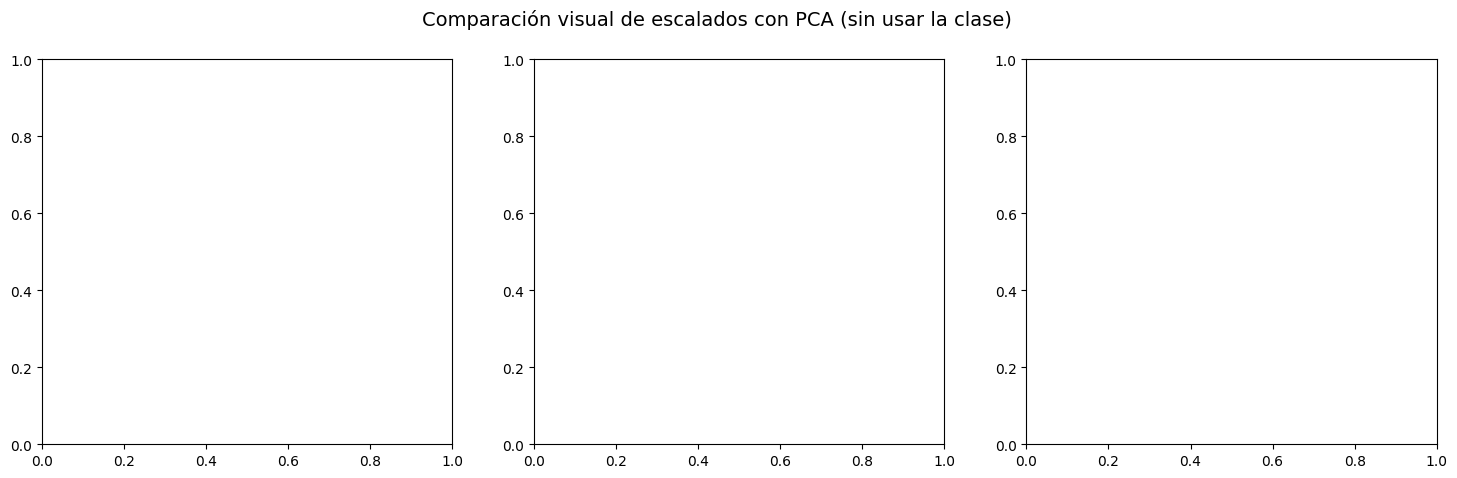

In [143]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # fig tiene todos los gráficos y axes es la lista de subgráficos
fig.suptitle("Comparación visual de escalados con PCA (sin usar la clase)", fontsize=14)

### Iterar por cada scaler

Recorremos cada scaler. En cada iteración:
1. Aplicamos el escalado a los datos originales (`X`).
2. Aplicamos PCA a los datos escalados, reduciendo de muchas dimensiones a solo 2.
3. Mostramos los datos proyectados con `scatter`.

NOTA: Nos daba un error raro si separabamos el codigo en partes, así que hemos vuelto a poner el codigo completo aquí

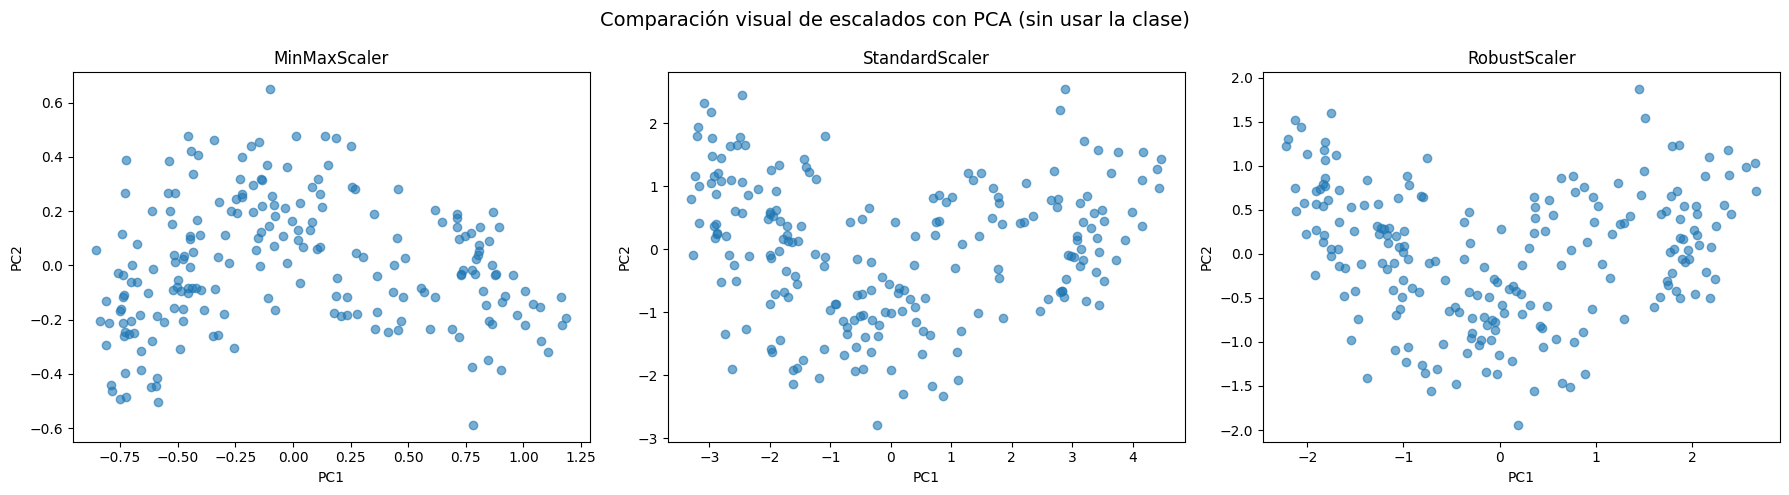

In [144]:

scalers = {
    "MinMaxScaler": MinMaxScaler(),
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler()
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Comparación visual de escalados con PCA (sin usar la clase)", fontsize=14)


for ax, (nombre, scaler) in zip(axes, scalers.items()):
    # Escalamos los datos
    """Transformamos los datos `X` con el scaler actual. 
     El resultado es una nueva versión de los datos en la que todos los
     atributos tienen una escala similar (según el tipo de scaler)."""
    X_scaled = scaler.fit_transform(X)
    
    # Aplicamos PCA con 2 componentes para reducir los datos a 2D y así poder ver el gráfico
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled) # aquí "aprende" de los datos y el transform aplica la transformación
    
    # Dibujamos el gráfico 2D
    ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
    ax.set_title(nombre)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout() # así no solapan
plt.show()

### Análisis visual de los escalados

Los tres gráficos muestran cómo quedan distribuidos los datos tras aplicar PCA a cada tipo de escalado.

- **MinMaxScaler**: los puntos forman una especie de “n”. Este tipo de escalado puede distorsionar un poco la estructura si hay valores extremos (outliers), ya que comprime todos los datos entre 0 y 1.

- **StandardScaler** y **RobustScaler**: ambos muestran una forma más clara de “U” o “V”, con una separación aparente entre grupos. Esto parece indicar que podrían conservar mejor la estructura real de los datos.

En general, **StandardScaler** es una buena opción por defecto, ya que estandariza los datos centrando la media y ajustando la desviación típica.

**PIPELINE**

Ahora vamos a compactar el bloque en una pipeline (asi es reutilizable el código).

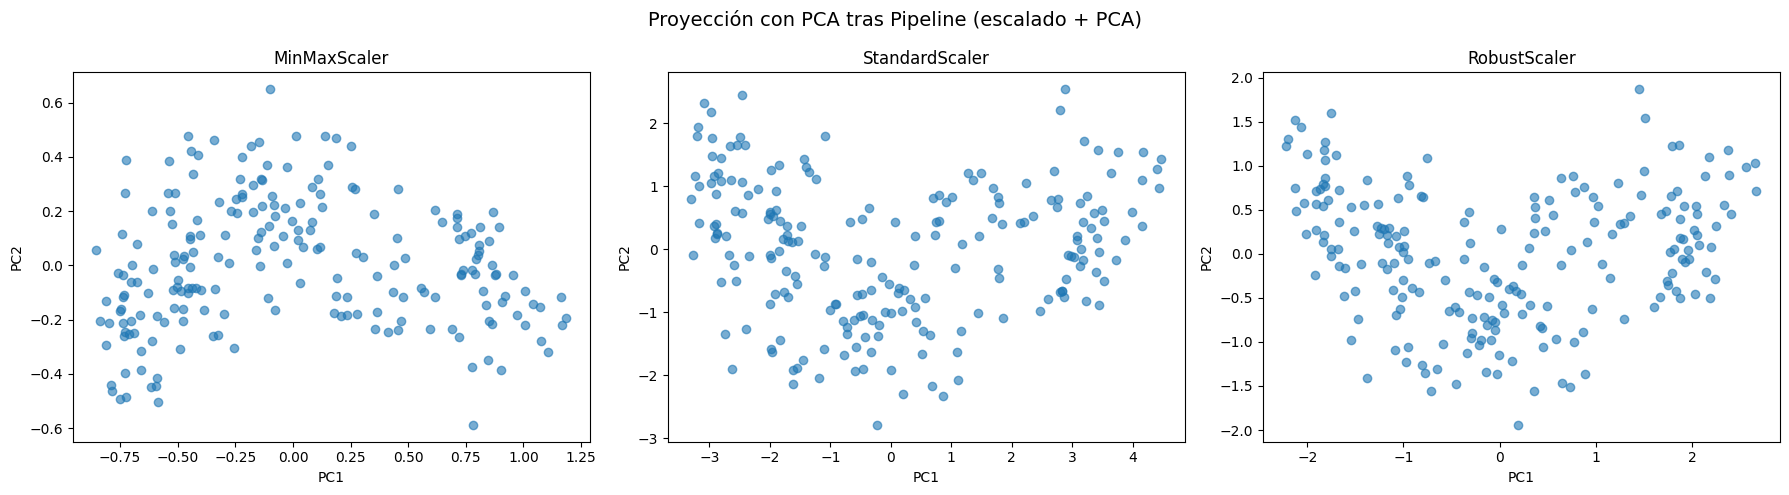

In [145]:

# Definimos los tres pipelines
pipelines = {
    "MinMaxScaler": Pipeline([
        ('scaler', MinMaxScaler()),
        ('pca', PCA(n_components=2))
    ]),
    "StandardScaler": Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=2))
    ]),
    "RobustScaler": Pipeline([
        ('scaler', RobustScaler()),
        ('pca', PCA(n_components=2))
    ])
}

# Creamos los subplots para visualizar
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Proyección con PCA tras Pipeline (escalado + PCA)", fontsize=14)

for ax, (nombre, pipe) in zip(axes, pipelines.items()):
    X_pca = pipe.fit_transform(X)
    ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
    ax.set_title(nombre)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

# **Clustering**

Aplicamos el algoritmo K-Means sobre los datos previamente escalados con StandardScaler. Como solo hay 3 tipos de semillas en el dataset original, vamos a probar con `k = 3`.

Visualizamos el resultado sobre la proyección en 2D obtenida con PCA.

El clustering, dado un conjunto de datos sin etiquetas (sin saber a que tipo de semilla pertenecen), agrupa automaticamente los datos parecidos formando clusters, así podremos descubrir los tipos de semilla que hay.

Con K-means elegimos el número de grupos (sabemos que hay 3 semillas, asi que elegimos que haya 3 grupos). El algoritmo los irá ajustando al centro más cercano.

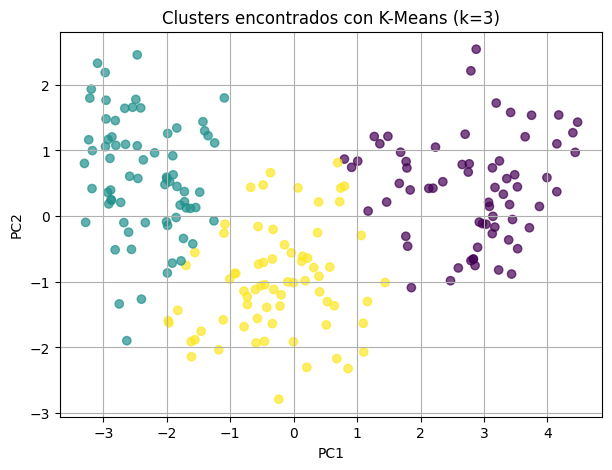


[K-Means]
Cluster 0: 67 puntos
Cluster 1: 72 puntos
Cluster 2: 71 puntos
Outliers: 0 (K-Means no detecta outliers por defecto)


In [146]:
from collections import Counter
# Volvemos a escalar y reducir con StandardScaler + PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

# Aplicamos K-Means con k=3
kmeans = KMeans(n_clusters=3, random_state=0)
# ¡Usamos los datos escalados, no los PCA!
labels_kmeans = kmeans.fit_predict(X_scaled)  # PCA reduce los datos a 2d y puede perder detalles

# Visualizamos los clusters en el plano PCA (en 2d si podemos verlo, pero los datos sin pca tienen mas dimensiones)
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='viridis', alpha=0.7)
plt.title("Clusters encontrados con K-Means (k=3)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# Mostrar conteo
conteo = Counter(labels_kmeans)
print("\n[K-Means]")
for c in sorted(conteo):
    print(f"Cluster {c}: {conteo[c]} puntos")
print("Outliers: 0 (K-Means no detecta outliers por defecto)")

Podemos observar los 3 grupos. A continuación probaremos otras técnicas de clusters, empezando por el clustering jerárquico.

## Clustering Jerárquico

Técnica de agrupamiento que **no requiere definir de antemano el número de clusters**. Funciona construyendo una jerarquía de agrupaciones que se pueden ver con un **dendrograma** (una especie de árbol de fusiones).

Hay dos formas principales:
- **Aglomerativo (bottom-up)**: empieza considerando cada punto como un cluster y va fusionando los más cercanos.
- **Divisivo (top-down)**: empieza con todos los puntos en un solo grupo y los divide.

En esta práctica usamos el enfoque **aglomerativo**, que es el más común.

### ¿Cómo se decide qué puntos se agrupan?
Depende del criterio de enlace (`linkage`), que define la "distancia" entre clusters:

- `'single'`: distancia mínima entre puntos de dos clusters.
- `'complete'`: distancia máxima entre puntos de dos clusters.
- `'average'`: distancia promedio entre todos los puntos de dos clusters.
- `'ward'`: minimiza la varianza dentro de los clusters (solo funciona con `euclidean`).

### ¿Qué vamos a hacer?
1. Aplicar clustering jerárquico a los datos escalados.
2. Probar distintos métodos de `linkage`.
3. Dibujar los resultados en 2D usando la proyección de PCA.
4. Evaluar la separación visual de los clusters (sin usar la clase aún).



[Linkage: single]
Cluster 0: 3 puntos
Cluster 1: 1 puntos
Cluster 2: 206 puntos

[Linkage: complete]
Cluster 0: 90 puntos
Cluster 1: 68 puntos
Cluster 2: 52 puntos

[Linkage: average]
Cluster 0: 65 puntos
Cluster 1: 75 puntos
Cluster 2: 70 puntos

[Linkage: ward]
Cluster 0: 73 puntos
Cluster 1: 70 puntos
Cluster 2: 67 puntos


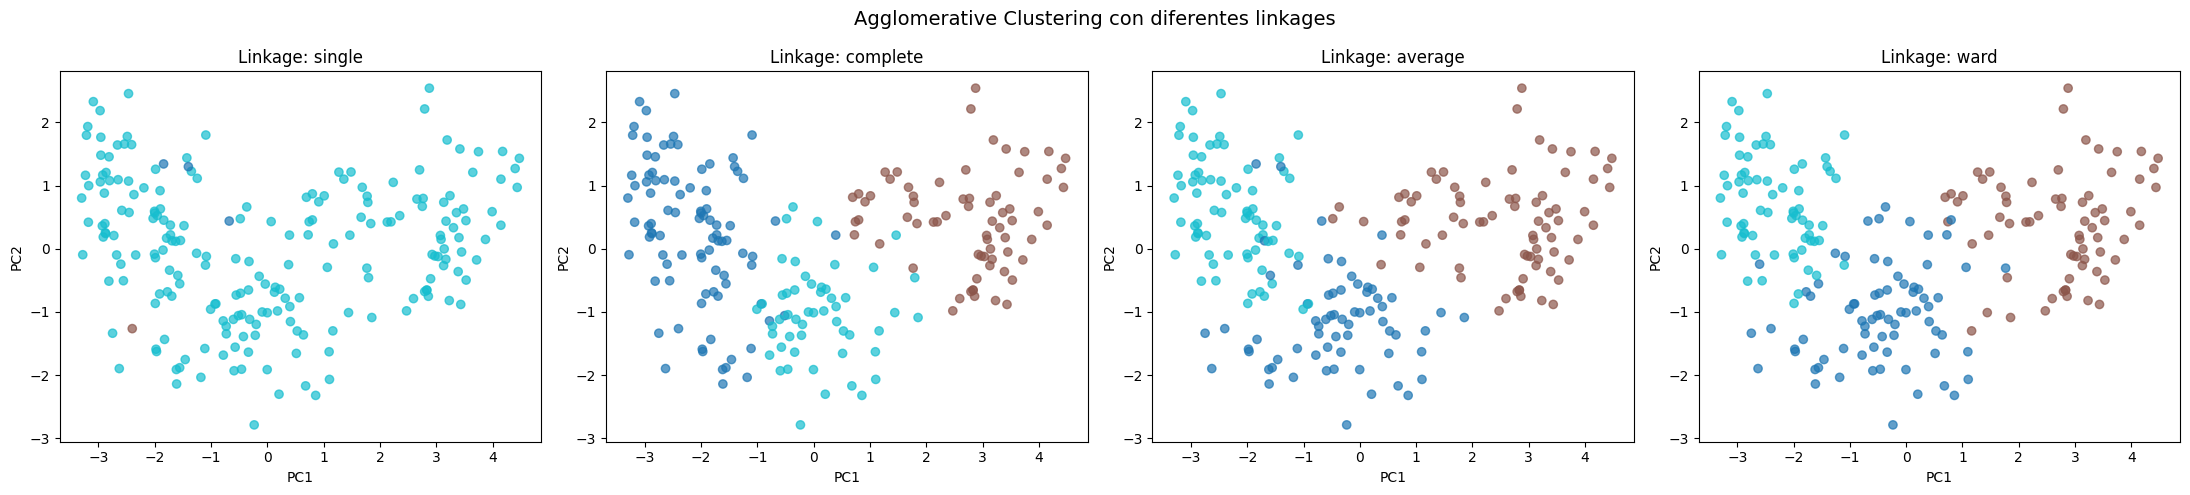

In [147]:
from sklearn.cluster import AgglomerativeClustering

X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

linkage_methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Agglomerative Clustering con diferentes linkages", fontsize=14)

for ax, method in zip(axes, linkage_methods):
    model = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = model.fit_predict(X_scaled)

    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', alpha=0.7)
    ax.set_title(f"Linkage: {method}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

    # Mostrar conteo
    conteo = Counter(labels)
    print(f"\n[Linkage: {method}]")
    for c in sorted(conteo):
        print(f"Cluster {c}: {conteo[c]} puntos")
    

plt.tight_layout()
plt.show()

## Clustering con DBSCAN

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** es un algoritmo de clustering basado en densidad. A diferencia de K-Means o el clustering jerárquico, **no necesita que especifiquemos cuántos clusters queremos**.

Funciona así:
- Agrupa puntos cercanos (dentro de un radio `eps`) y que tienen al menos `min_samples` vecinos.
- Detecta automáticamente regiones densas (clusters) y puntos aislados (outliers).
- Es útil para detectar **clusters de forma irregular** y **ruido en los datos**.

### ¿Qué vamos a hacer?
1. Escalar los datos.
2. Probar valores de `eps` y `min_samples`.
3. Visualizar el resultado proyectado en 2D con PCA.
4. Observar si DBSCAN detecta agrupaciones y puntos ruidosos.

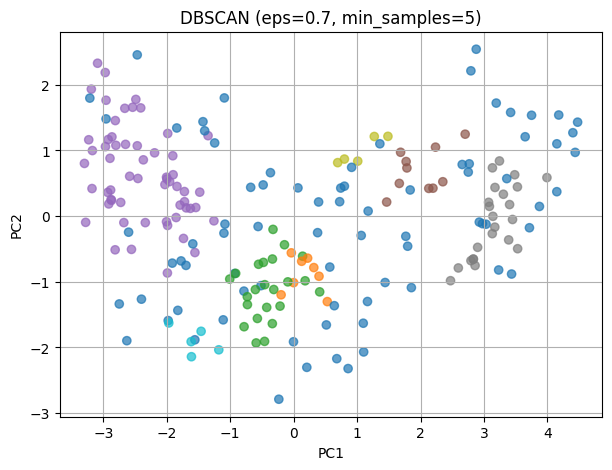

Número de clusters encontrados (sin contar outliers): 7
Número de outliers detectados: 78


In [148]:
from sklearn.cluster import DBSCAN
def aplicar_dbscan(X, eps=0.7, min_samples=5):
    """
    Aplica DBSCAN a los datos X, visualiza el resultado proyectado en PCA
    y muestra el número de clusters y outliers encontrados.
    
    Parámetros:
    - X: matriz de datos original (no escalada)
    - eps: radio para DBSCAN
    - min_samples: número mínimo de puntos por vecindario
    """
    # Escalado y PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_pca = PCA(n_components=2).fit_transform(X_scaled)

    # DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)

    # Visualización
    plt.figure(figsize=(7, 5))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', alpha=0.7)
    plt.title(f"DBSCAN (eps={eps}, min_samples={min_samples})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

    # Info de clusters
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_outliers = (labels == -1).sum()
    print(f"Número de clusters encontrados (sin contar outliers): {n_clusters}")
    print(f"Número de outliers detectados: {n_outliers}")

aplicar_dbscan(X)

Tenemos que ajustar mejor, intentaremos reducir los outliers y los clusters, para ello modificaremos eps (si es muy bajo habrá muchos outliers, si es muy alto los clusters quedan mezclados). Sabemos que hay 3 semillas, buscaremos el modelo que encuentre 3 clusters.

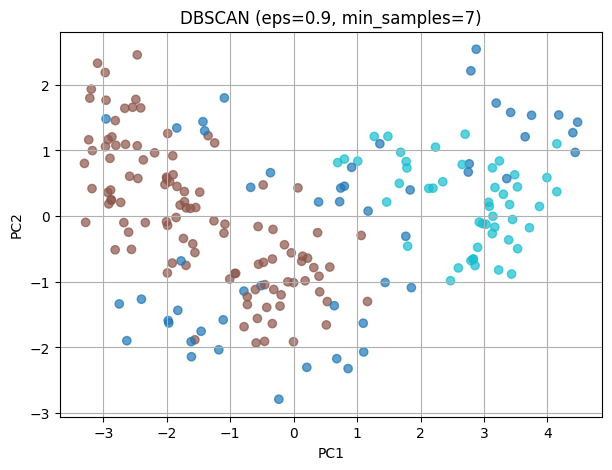

Número de clusters encontrados (sin contar outliers): 2
Número de outliers detectados: 52


In [149]:
aplicar_dbscan(X, eps=0.9, min_samples=7)

En vez de hacerlo manualmente, vamos a probar a ajustarlo con un bucle en una función que buscará tener el minimo numero de outliers y los clusters que esperamos tener.

In [150]:
def encontrar_dbscan_con_clusters(X, eps_list, min_samples_list, cluster_objetivo=3):
    """
    Busca la mejor combinación (eps, min_samples) que dé exactamente 'cluster_objetivo' clusters.
    De entre ellas, elige la que tenga menos outliers.
    Muestra un gráfico y devuelve (eps, min_samples) óptimos.
    """
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    from sklearn.cluster import DBSCAN

    X_scaled = StandardScaler().fit_transform(X)
    X_pca = PCA(n_components=2).fit_transform(X_scaled)

    mejor = None
    min_outliers = float('inf')

    for eps in eps_list:
        for min_s in min_samples_list:
            db = DBSCAN(eps=eps, min_samples=min_s)
            labels = db.fit_predict(X_scaled)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_outliers = (labels == -1).sum()

            if n_clusters == cluster_objetivo and n_outliers < min_outliers:
                mejor = {
                    'eps': eps,
                    'min_samples': min_s,
                    'labels': labels,
                    'outliers': n_outliers
                }
                min_outliers = n_outliers

    if mejor:
        print(f"Mejor combinación que da {cluster_objetivo} clusters:")
        print(f"eps = {mejor['eps']}, min_samples = {mejor['min_samples']}")
        print(f"Outliers detectados: {mejor['outliers']}")

        plt.figure(figsize=(6, 4))
        plt.scatter(X_pca[:, 0], X_pca[:, 1], c=mejor['labels'], cmap='tab10', alpha=0.7)
        plt.title(f"DBSCAN óptimo: eps={mejor['eps']}, min_samples={mejor['min_samples']}")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.grid(True)
        plt.show()

        return mejor['eps'], mejor['min_samples']
    else:
        print(f"No se encontró ninguna combinación que dé exactamente {cluster_objetivo} clusters.")
        return None, None

Y vamos a probarlo

Mejor combinación que da 3 clusters:
eps = 0.97, min_samples = 7
Outliers detectados: 32


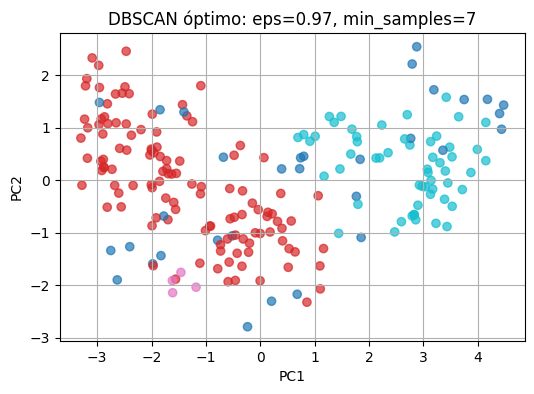

(0.97, 7)

In [151]:
eps_list = [0.96,0.97, 0.98]
min_samples_list = [3, 4, 5, 6, 7, 8, 9]

encontrar_dbscan_con_clusters(X, eps_list, min_samples_list, cluster_objetivo=3)

Vemos que la mejor combinacion en este caso es eps=0.97 y min_samples = 7

## Comparación de resultados

Podemos ver que K-Means es la mejor técnica ya que se observan grupos buien detallados y con zonas definidas y regulares. El clustering jerárquico también da buenos resultados pero las zonas son un poco mas entremezcladas. El DBScan da los peores resultados, con zonas muy entremezcladas.

En adelante, elegiremos K-Means con k =3.